In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [2]:
df = pd.read_csv("vgsales.csv")

In [3]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
print(df.shape)

(16598, 11)


In [5]:
df = df.dropna(subset=["Year"])

In [6]:
df = df[df["Year"] <= 2016]

In [7]:
df["Year"] = df["Year"].astype(int)

In [8]:
def era_group(year):
    if 1980 <= year <= 1989:
        return "1980s"
    elif 1990 <= year <= 1999:
        return "1990s"
    elif 2000 <= year <= 2009:
        return "2000s"
    elif 2010 <= year <= 2016:
        return "2010s"
df["Era"] = df["Year"].apply(era_group)

In [9]:
print(df["Era"].value_counts())

Era
2000s    9208
2010s    5141
1990s    1769
1980s     205
Name: count, dtype: int64


In [10]:
genre_pivot = pd.pivot_table(
    df,
    values="Global_Sales",
    index="Era",
    columns="Genre",
    aggfunc="sum")
print(genre_pivot.head())

Genre  Action  Adventure  Fighting    Misc  Platform  Puzzle  Racing  \
Era                                                                    
1980s   51.18       4.78      7.24    8.45    122.27   62.73   12.10   
1990s  139.29      44.81    123.45   63.54    208.91   38.99  150.40   
2000s  858.91     124.16    231.28  487.58    377.28  119.26  440.58   
2010s  673.49      61.05     82.08  238.05    120.69   21.24  123.69   

Genre  Role-Playing  Shooter  Simulation  Sports  Strategy  
Era                                                         
1980s         15.25    59.79        0.51   32.28       NaN  
1990s        184.52    68.95       52.05  146.57     57.43  
2000s        418.35   434.66      266.27  805.59     80.10  
2010s        305.68   462.80       71.04  324.80     35.90  


In [11]:
genre_share = (
    genre_pivot.div(
        genre_pivot.sum(axis=1),
        axis=0) * 100)
print(genre_share.round(2))

Genre  Action  Adventure  Fighting   Misc  Platform  Puzzle  Racing  \
Era                                                                   
1980s   13.59       1.27      1.92   2.24     32.47   16.66    3.21   
1990s   10.89       3.50      9.65   4.97     16.34    3.05   11.76   
2000s   18.49       2.67      4.98  10.50      8.12    2.57    9.49   
2010s   26.72       2.42      3.26   9.44      4.79    0.84    4.91   

Genre  Role-Playing  Shooter  Simulation  Sports  Strategy  
Era                                                         
1980s          4.05    15.88        0.14    8.57       NaN  
1990s         14.43     5.39        4.07   11.46      4.49  
2000s          9.01     9.36        5.73   17.35      1.72  
2010s         12.13    18.36        2.82   12.89      1.42  


In [12]:
genre_change = (
    genre_share.loc["2010s"] -
    genre_share.loc["1980s"]
).sort_values(ascending=False)
print(genre_change)

Genre
Action          13.129648
Role-Playing     8.078100
Misc             7.200638
Sports           4.314397
Simulation       2.683048
Shooter          2.484259
Racing           1.694211
Fighting         1.333918
Adventure        1.152810
Puzzle         -15.815128
Platform       -27.680216
Strategy              NaN
dtype: float64


In [13]:
platform_pivot = pd.pivot_table(
    df,
    values="Global_Sales",
    index="Era",
    columns="Platform",
    aggfunc="sum")

In [14]:
platform_share = (
    platform_pivot.div(
        platform_pivot.sum(axis=1),
        axis=0) * 100)
print(platform_share.round(2))

Platform   2600   3DO   3DS    DC     DS     GB   GBA    GC   GEN   GG  ...  \
Era                                                                     ...   
1980s     22.99   NaN   NaN   NaN   0.01  17.64   NaN   NaN   NaN  NaN  ...   
1990s       NaN  0.01   NaN  0.67    NaN  12.43   NaN   NaN  2.22  0.0  ...   
2000s       NaN   NaN   NaN  0.16  14.84   0.62  6.75  4.25   NaN  NaN  ...   
2010s       NaN   NaN  9.77   NaN   5.13    NaN   NaN   NaN   NaN  NaN  ...   

Platform   SAT   SCD   SNES  TG16    WS    Wii  WiiU   X360    XB  XOne  
Era                                                                      
1980s      NaN   NaN    NaN   NaN   NaN    NaN   NaN    NaN   NaN   NaN  
1990s     2.63  0.15  15.64  0.01  0.04    NaN   NaN    NaN   NaN   NaN  
2000s      NaN   NaN    NaN   NaN  0.02  14.59   NaN   8.89  5.43   NaN  
2010s      NaN   NaN    NaN   NaN   NaN   9.22  3.25  22.10   NaN   5.6  

[4 rows x 31 columns]


In [15]:
publisher_sales = (
    df.groupby(["Era", "Publisher"])
    ["Global_Sales"]
    .sum()
    .reset_index())

In [16]:
top_publishers = (
    publisher_sales
    .sort_values(
        ["Era", "Global_Sales"],
        ascending=[True, False])
    .groupby("Era")
    .head(3))
print(top_publishers)

       Era                    Publisher  Global_Sales
23   1980s                     Nintendo        234.92
3    1980s                        Atari         41.30
1    1980s                   Activision         18.41
155  1990s                     Nintendo        364.56
185  1990s  Sony Computer Entertainment        171.73
81   1990s              Electronic Arts         84.98
440  2000s                     Nintendo        883.89
312  2000s              Electronic Arts        647.49
238  2000s                   Activision        381.45
633  2010s              Electronic Arts        360.92
730  2010s                     Nintendo        301.06
575  2010s                   Activision        295.65


In [17]:
publisher_presence = (
    top_publishers.groupby("Publisher")
    ["Era"]
    .nunique()
    .sort_values(ascending=False))
print(publisher_presence)

Publisher
Nintendo                       4
Activision                     3
Electronic Arts                3
Atari                          1
Sony Computer Entertainment    1
Name: Era, dtype: int64


In [18]:
top_genres = (
    df.groupby("Genre")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index)

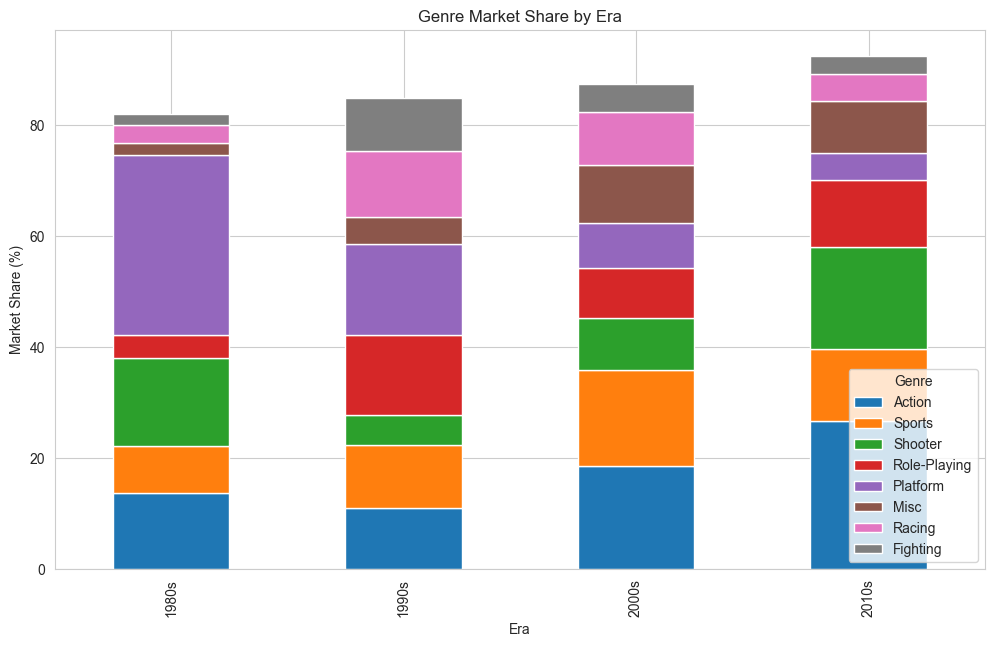

In [19]:
genre_share[top_genres].plot(
    kind="bar",
    stacked=True,
    figsize=(12,7))
plt.title("Genre Market Share by Era")
plt.ylabel("Market Share (%)")
plt.show()

In [20]:
top_platforms = (
    df.groupby("Platform")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index)

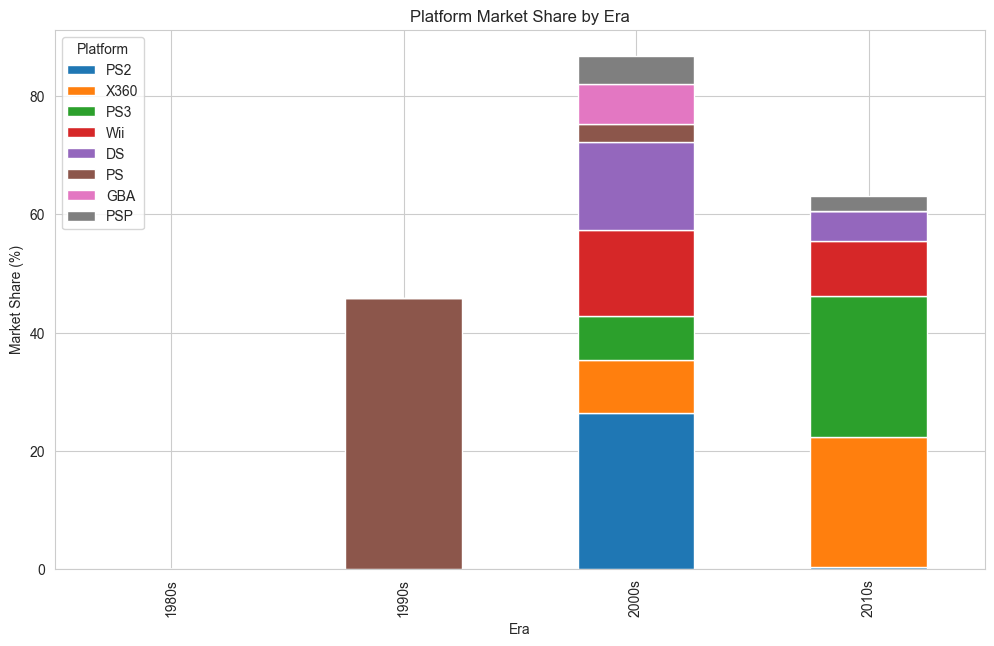

In [21]:
platform_share[top_platforms].plot(
    kind="bar",
    stacked=True,
    figsize=(12,7))
plt.title("Platform Market Share by Era")
plt.ylabel("Market Share (%)")
plt.show()

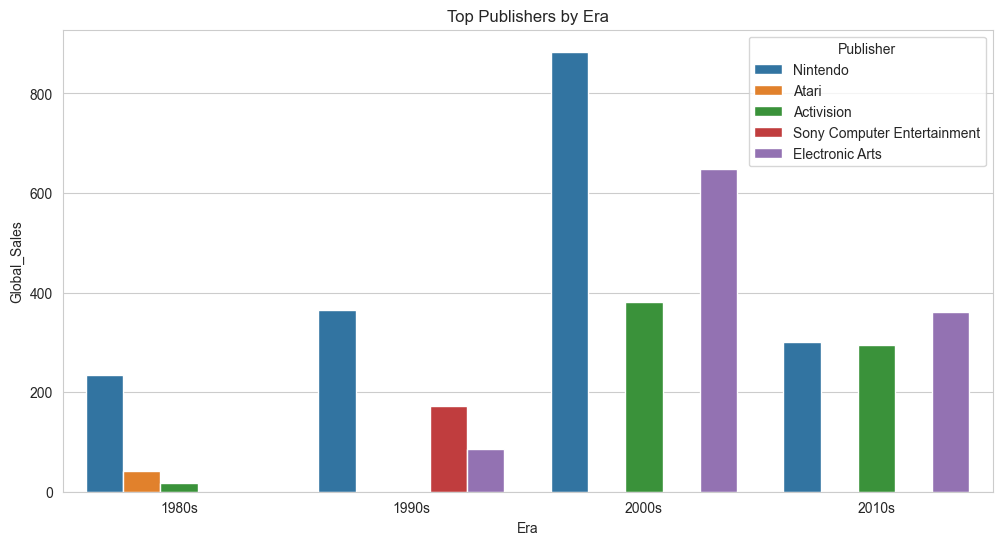

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_publishers,
    x="Era",
    y="Global_Sales",
    hue="Publisher")
plt.title("Top Publishers by Era")
plt.show()

In [23]:
def cagr(start, end, periods):
    return (((end / start) ** (1 / periods)) - 1) * 100 # bonus

In [24]:
genre_cagr = {}
for genre in genre_share.columns:
    start = genre_share.loc["1980s", genre]
    end = genre_share.loc["2010s", genre]
    if start > 0 and end > 0:
        genre_cagr[genre] = round(
            cagr(start, end, 3),2)
print(genre_cagr)

{'Action': np.float64(25.28), 'Adventure': np.float64(24.03), 'Fighting': np.float64(19.2), 'Misc': np.float64(61.46), 'Platform': np.float64(-47.17), 'Puzzle': np.float64(-63.02), 'Racing': np.float64(15.16), 'Role-Playing': np.float64(44.14), 'Shooter': np.float64(4.97), 'Simulation': np.float64(175.06), 'Sports': np.float64(14.56)}


In [25]:
na_eu_ratio = (
    df.groupby("Genre")["NA_Sales"]
    .sum() /
    df.groupby("Genre")["EU_Sales"]
    .sum())
print(na_eu_ratio.sort_values(ascending=False).head()) # bonus

Genre
Puzzle      2.414605
Platform    2.222505
Fighting    2.207400
Misc        1.882331
Shooter     1.852665
dtype: float64


In [26]:
jp_na_ratio = (
    df.groupby("Genre")["JP_Sales"]
    .sum() /
    df.groupby("Genre")["NA_Sales"]
    .sum())
print(jp_na_ratio.sort_values(ascending=False).head())

Genre
Role-Playing    1.072741
Strategy        0.723229
Adventure       0.509602
Puzzle          0.464552
Fighting        0.394808
dtype: float64
